# Credit Cards Churned
In this project, we will analyze this dataset which contains information about credit cards customers and their information related to the total number of transactions made, their credit limit and so on.

This focus in finding a business solution related to the causes of customers leaving their credit cards services and improving it to make the customers change their opinion about the bank.

In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../datasets/BankChurners.csv")

### Drop null values

In [3]:
df = df.dropna()

### First rows of the dataset

In [4]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


### Shape of the dataset

In [5]:
df.shape

(10127, 23)

### Sumarry statistic of the dataset

In [6]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


### Total number of customers of each education level

In [7]:
educational_level_customers = df.groupby("Education_Level").sum()
print(educational_level_customers)

                     CLIENTNUM  \
Education_Level                  
College           750808020279   
Doctorate         332567750283   
Graduate         2311387331949   
High School      1487702837604   
Post-Graduate     381279298578   
Uneducated       1097734007196   
Unknown          1124172373452   

                                                    Attrition_Flag  \
Education_Level                                                      
College          Existing CustomerExisting CustomerExisting Cus...   
Doctorate        Existing CustomerAttrited CustomerExisting Cus...   
Graduate         Existing CustomerExisting CustomerExisting Cus...   
High School      Existing CustomerExisting CustomerExisting Cus...   
Post-Graduate    Existing CustomerExisting CustomerExisting Cus...   
Uneducated       Existing CustomerExisting CustomerExisting Cus...   
Unknown          Existing CustomerExisting CustomerExisting Cus...   

                 Customer_Age  \
Education_Level              

### Rename values related to gender for better reading

In [8]:
df = df.replace({"M":"Male","F":"Female"})

In [9]:
#Average customer transaction amount for each gender
average_transactions = df.groupby("Gender")["Total_Trans_Amt"].mean()
print(average_transactions)

Gender
Female    4324.318216
Male      4493.706228
Name: Total_Trans_Amt, dtype: float64


### Barplot which represents the total number of transactions of both genders for each education level

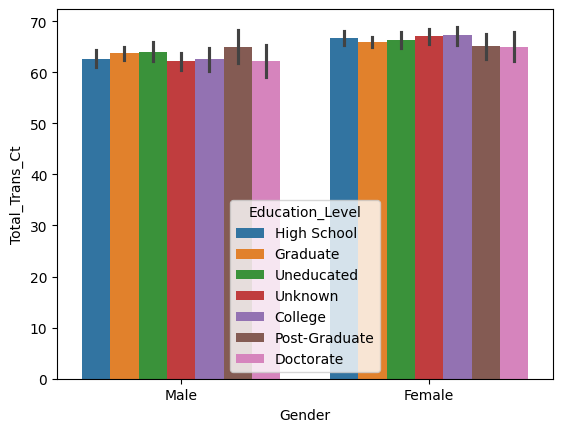

In [10]:
gender_transactions = sb.barplot(data=df,x="Gender",y="Total_Trans_Ct",hue="Education_Level")

We want to know how many customers are active

In [11]:
customers_flag = df.groupby("Attrition_Flag")["Attrition_Flag"].agg("count")
print(customers_flag)

Attrition_Flag
Attrited Customer    1627
Existing Customer    8500
Name: Attrition_Flag, dtype: int64


We find there are more existing customers than attritied customers.

We can see if there is a correlation between marital status and their flag.

There is no an exact correlation

<Axes: xlabel='Attrition_Flag'>

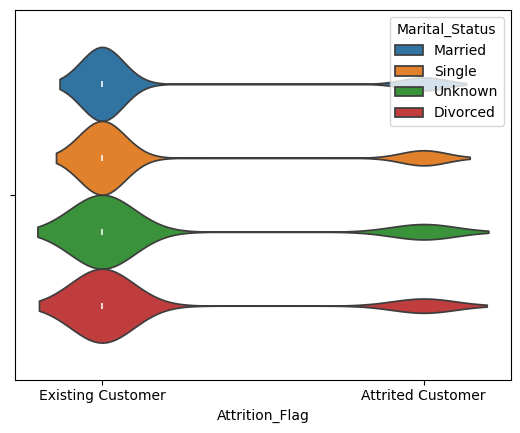

In [12]:
sb.violinplot(data=df,x="Attrition_Flag",hue="Marital_Status")


We can see if there is a possible correlation between age of customers and their decision

### Filter of attrited customers

In [13]:
no_existing_customers = df["Attrition_Flag"] == "Attrited Customer"
print(no_existing_customers)


0        False
1        False
2        False
3        False
4        False
         ...  
10122    False
10123     True
10124     True
10125     True
10126     True
Name: Attrition_Flag, Length: 10127, dtype: bool


### Scatterplot which determines the relationship between the age of customers and their activity in the bank service

Text(0.5, 1.0, 'Customer State')

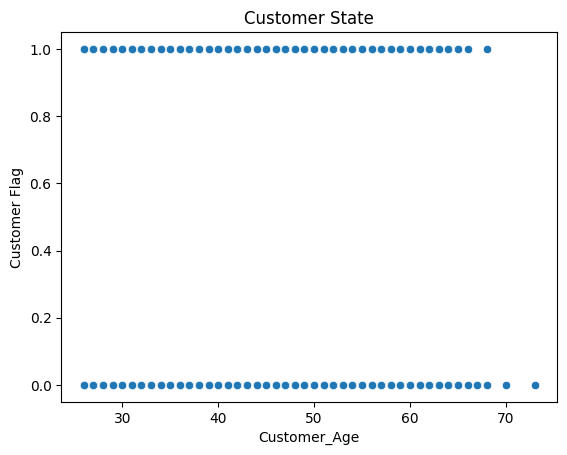

In [14]:
customers_plot = sb.scatterplot(data=df,x="Customer_Age",y=no_existing_customers)
customers_plot.set_ylabel("Customer Flag")
customers_plot.set_title("Customer State")

### Total count of customers with each type of card 

In [15]:
#We get the total amount of customers with each credit card category
credit_cards_type = df.groupby("Card_Category")["Card_Category"].agg("count")
#We order the quantity in ascending order
sorted_credit_cards = credit_cards_type.sort_values(ascending=True)
#Print the result
print(sorted_credit_cards)

Card_Category
Platinum      20
Gold         116
Silver       555
Blue        9436
Name: Card_Category, dtype: int64


### Conclusions and recommendations

The conclusion of this situation is that there is no aspect visible that could influence on the current loss of customers.
Some aspects of a company's customers are not under the business control, so we have to find a solution or new feature to improve the service.

The recommendations provided for this problem might be establishing a better communication with the current customers to prevent more losses and attract future customers.